# 1. Import necessary libraries

In [1]:
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import numpy as np

# 2. Import Data

In [3]:
(X_train, _), (X_test, _) = keras.datasets.mnist.load_data(path="mnist.npz")

In [5]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

# 3. Data preparation

## 3.1 add channel

In [7]:
X_train = X_train.reshape(60000, 28, 28,1)
X_test = X_test.reshape(10000, 28, 28,1)

In [8]:
X_train.shape, X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [9]:
X_train.min(), X_train.max()

(np.uint8(0), np.uint8(255))

In [10]:
X_test.min(), X_test.max()

(np.uint8(0), np.uint8(255))

## 3.2 Normalize the values

In [11]:
X_train = X_train/255.0
X_test = X_test/255.0

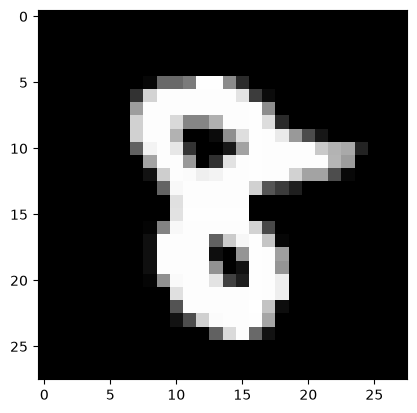

In [14]:
plt.imshow(X_train[2400],cmap = 'grey')

## 3.3 Add noise to the image

In [15]:
X_train_noise = X_train + 0.3 * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_noise = X_test + 0.3 * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)

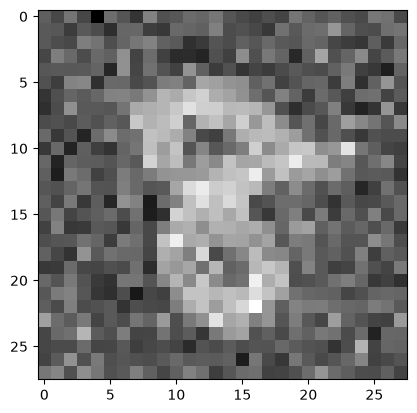

In [17]:
plt.imshow(X_train_noise[2400],cmap = 'grey')

In [18]:
X_train_noise.min(), X_train_noise.max()

(np.float64(-1.6361451200053059), np.float64(2.515171554944339))

## 3.4 Add the clip

In [20]:
X_train_clipped = np.clip(a = X_train_noise,a_min=0.,a_max=1.)
X_test_clipped = np.clip(a = X_test_noise,a_min=0.,a_max=1.)

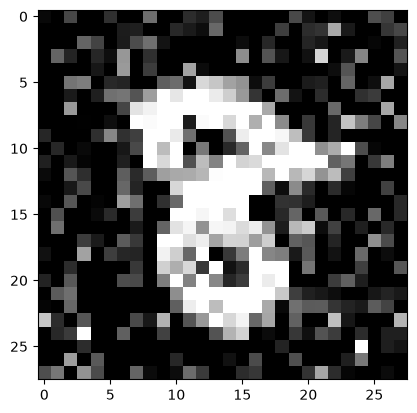

In [22]:
plt.imshow(X_train_clipped[2400],cmap = 'grey')

# 4. Model Building

In [24]:
from keras import Sequential
from keras.layers import Conv2D, MaxPool2D,UpSampling2D

import warnings 
warnings.filterwarnings("ignore")

In [31]:
model = Sequential()
# Encode  - compress the info
model.add(Conv2D(filters = 32,kernel_size = (3,3),strides=(1, 1),padding='same',activation='relu',input_shape=(28,28,1)))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(filters = 8,kernel_size = (3,3),strides=(1, 1),padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

# Decode - Expand the info
model.add(Conv2D(filters = 8,kernel_size = (3,3),strides=(1, 1),padding='same',activation='relu'))
model.add(UpSampling2D(size=(2, 2)))
model.add(Conv2D(filters =32,kernel_size = (3,3),strides=(1, 1),padding='same',activation='relu'))
model.add(UpSampling2D(size=(2, 2)))
model.add(Conv2D(filters =1,kernel_size = (3,3),strides=(1, 1),padding='same',activation='relu'))

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 14, 14, 8)           │           2,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 7, 7, 8)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 7, 7, 8)             │             584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_3 (UpSampling2D)       │ (None, 14, 14, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 14, 14, 32)          │           2,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_4 (UpSampling2D)       │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,841 (22.82 KB)

 Trainable params: 5,841 (22.82 KB)

 Non-trainable params: 0 (0.00 B)

# 5. Model Compile

In [32]:
model.compile(optimizer='adam',loss='mean_squared_error',metrics=['accuracy'])

# 6. Model Training

In [33]:
model.fit(x=X_train_clipped,y=X_train,batch_size=32,epochs=5,validation_data = (X_test, X_test_clipped))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.8131 - loss: 0.0133 - val_accuracy: 0.4668 - val_loss: 0.0512
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8144 - loss: 0.0085 - val_accuracy: 0.4674 - val_loss: 0.0519
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8146 - loss: 0.0077 - val_accuracy: 0.4678 - val_loss: 0.0499
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8147 - loss: 0.0073 - val_accuracy: 0.4679 - val_loss: 0.0507
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8147 - loss: 0.0071 - val_accuracy: 0.4681 - val_loss: 0.0497


# 7. Model Evaluation

In [34]:
model.evaluate(X_test_clipped, X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8139 - loss: 0.0069


[0.006922988686710596, 0.8138568997383118]

# 8. Model Prediction

In [35]:
y_pred = model.predict(X_test_clipped)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


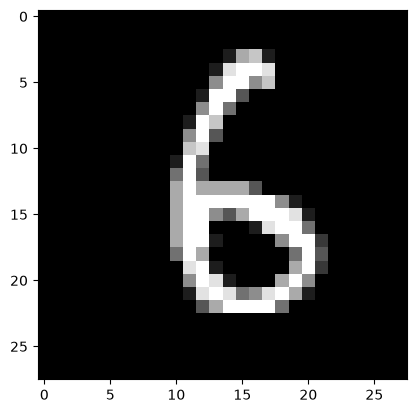

In [36]:
plt.imshow(X_test[3000], cmap='grey')

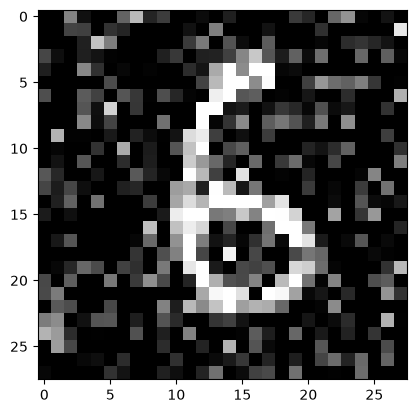

In [37]:
plt.imshow(X_test_clipped[3000], cmap='grey')

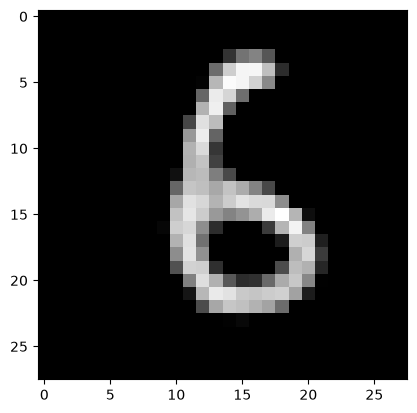

In [38]:
plt.imshow(y_pred[3000], cmap='grey')

# 9.Save the intel file

In [39]:
model.save("denoising.h5")